## Import library


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load dataset

In [3]:
total = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_total.csv")
core = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_core.csv")
edge = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_edge.csv")

metrics = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/field_metrics.csv")

## Keep useful columns

In [4]:
total = total[[
    'field_id',
    'NDVI_total'
]]

edge = edge[[
    'field_id',
    'NDVI_edge'
]]

core = core[[
    'field_id',
    'NDVI_core'
]]

metrics = metrics[[
    'field_id',
    'area_m2',
    'shape_inde',
    'core_area',
    'total_area',
    'edge_ratio',
    'size_class'
]]


## Merge datasets

In [5]:
df = total.merge(core, on='field_id')
df = df.merge(edge, on='field_id')
df = df.merge(metrics, on='field_id')

## Create edge contamination metrics

In [6]:
# Difference
df['edge_effect']=(
        df['NDVI_edge']
        -
        df['NDVI_core']
)

# Absolute

df['abs_edge_effect']=(
        df['edge_effect']
        .abs()
)

## Area versus edge effect

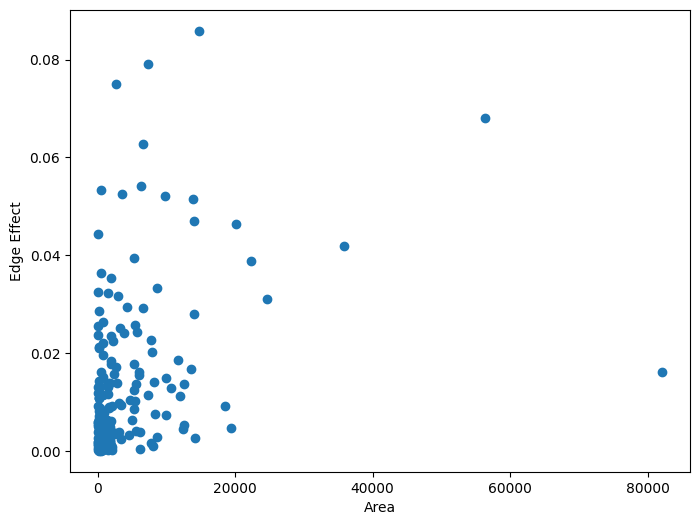

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(

df['area_m2'],
df['abs_edge_effect']

)


plt.xlabel("Area")

plt.ylabel("Edge Effect")


plt.show()


## Shape effect

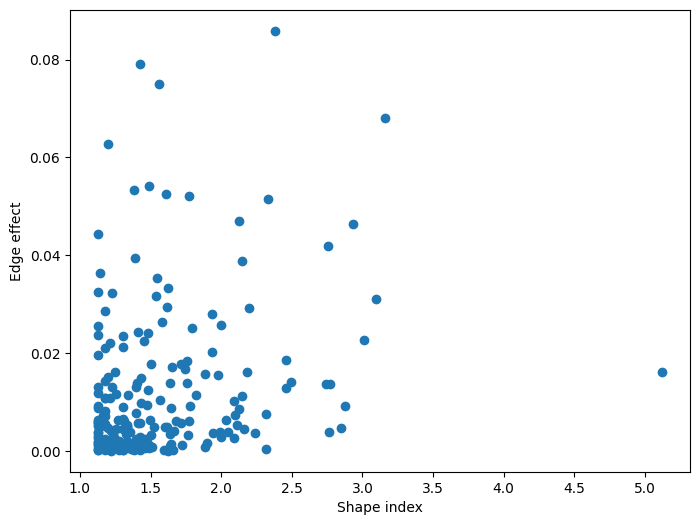

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(

df['shape_inde'],
df['abs_edge_effect']

)


plt.xlabel("Shape index")

plt.ylabel("Edge effect")


plt.show()


## Boxplot

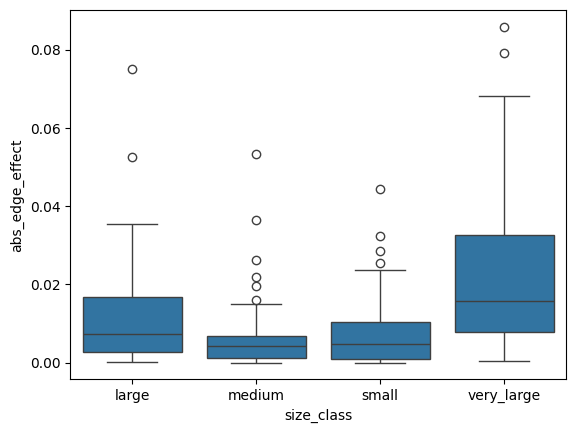

In [9]:
sns.boxplot(

x='size_class',
y='abs_edge_effect',
data=df

)

plt.show()

In [10]:
corr=df.corr(
numeric_only=True
)

corr['abs_edge_effect']

,abs_edge_effect
field_id,0.246003
NDVI_total,-0.220036
NDVI_core,-0.230607
NDVI_edge,-0.175711
area_m2,0.363774
shape_inde,0.250050
core_area,0.369127
total_area,0.363889
edge_ratio,-0.346445
edge_effect,0.602448


## Reliability threshold

In [11]:
threshold=0.05

stable=df[
df['abs_edge_effect']
<
threshold
]

In [12]:
stable['area_m2'].min()

90.10382570015446

NDVI estimates became relatively stable for fields larger than approximately 180 m².

## Histogram

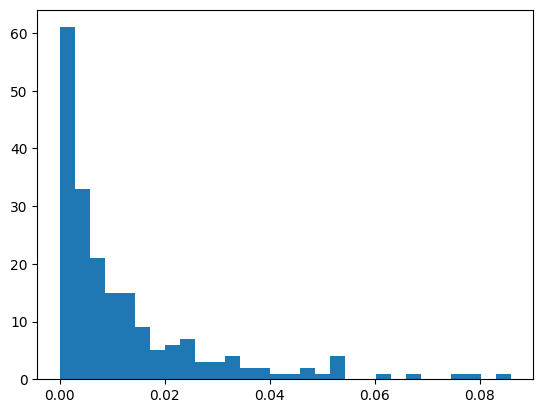

In [13]:
plt.hist(

df['abs_edge_effect'],
bins=30

)


plt.show()

In [14]:
df.to_csv(

"master_analysis.csv",
index=False

)